#Trabajo Práctico Final: Introducción en la Inteligencia Artificial

##1. Análisis del dataset
tipo de información, preprocesado de los datos (si se ha hecho o si
viene hecho), campos presentes (si los hay), distribución de los mismos.

El dataset que utilizaremos es Customer Support Tickets, publicado por Tobias Bueck (Tobi-Bueck) en Hugging Face. Se trata de un conjunto de tickets de soporte técnico y atención al cliente etiquetados para tareas de clasificación y análisis de tickets.

El dataset contiene información textual correspondiente a correos electrónicos enviados a servicios de soporte, junto con etiquetas asignadas por agentes de soporte.
https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets

In [1]:
from datasets import load_dataset

ds = load_dataset("Tobi-Bueck/customer-support-tickets")

README.md:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [2]:
#utilizaremos pandas para manipular el dataset

import pandas as pd

df = ds["train"].to_pandas()

print(df.shape)
df.head()

(61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [3]:
# Vemos las distintas columnas del dataset en el informe se explica que representa cada una
i = 1
for col in df.columns:
    print(f"Columna {i}: {col}")
    i += 1

Columna 1: subject
Columna 2: body
Columna 3: answer
Columna 4: type
Columna 5: queue
Columna 6: priority
Columna 7: language
Columna 8: version
Columna 9: tag_1
Columna 10: tag_2
Columna 11: tag_3
Columna 12: tag_4
Columna 13: tag_5
Columna 14: tag_6
Columna 15: tag_7
Columna 16: tag_8


####*Aclaración*
El dataset provisto tiene tickets en alemán,por ahora nuestro enfoque es solamente en inglés por lo que filtraremos los datos por la columna de lenguaje a inglés únicamente

In [4]:
df_en = df[df["language"] == "en"].copy()

print(df_en.shape)
df_en.head()

(28261, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [5]:
#algunos ejemplos de inputs por categorías
for clase in df_en["queue"].unique():

    ejemplo = df_en[df_en["queue"] == clase].iloc[0]

    print("="*80)
    print("queue:", clase)
    print()
    print(ejemplo["body"][:400])
    print()

queue: Technical Support

Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\n\nCould you please provide an update on th

queue: Returns and Exchanges

Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your website. As a potential customer aiming to develop a seamlessly interconnected home environment, it is essential to understand how your products interact with various smart home platforms.\n\nCould you k

queue: Billing and Payments

Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification a



##1.1 Distribuciones de los campos

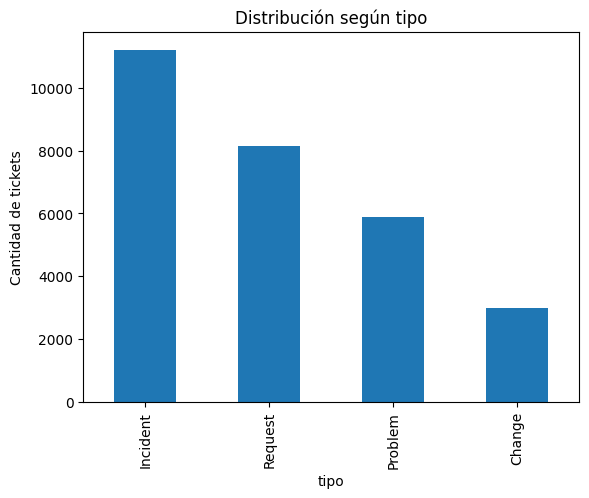

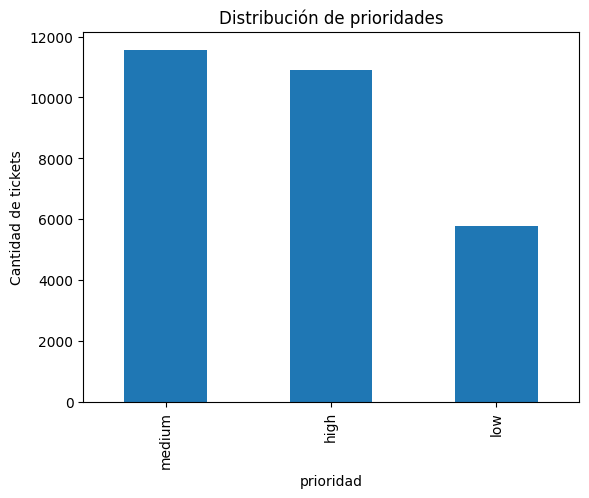

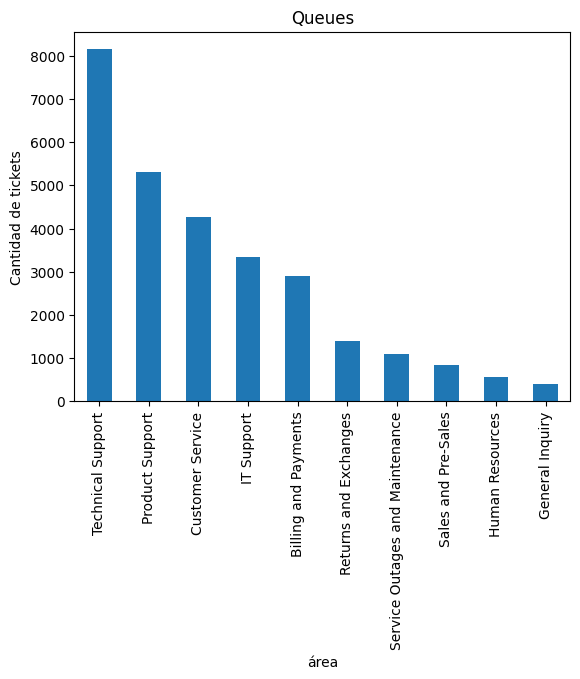

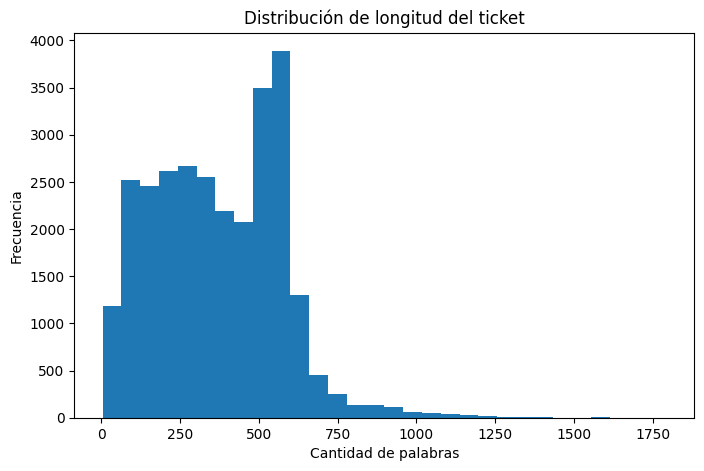

In [6]:
import matplotlib.pyplot as plt

#tipo
type_counts = df_en["type"].value_counts()
type_counts.plot(kind="bar")

plt.title("Distribución según tipo")
plt.ylabel("Cantidad de tickets")
plt.xlabel("tipo")
plt.show()

#prioridad
priority_counts = df_en["priority"].value_counts()
priority_counts.plot(kind="bar")

plt.title("Distribución de prioridades")
plt.ylabel("Cantidad de tickets")
plt.xlabel("prioridad")
plt.show()

#categoria
queue_counts = df_en["queue"].value_counts()
queue_counts.head(10).plot(kind="bar")

plt.title("Queues")
plt.ylabel("Cantidad de tickets")
plt.xlabel("área")
plt.show()

#Distribución de longitud de Body
plt.figure(figsize=(8,5))

# Calculate the length of the 'body' for non-null values
body_lengths = df_en["body"].dropna().apply(len)
plt.hist(body_lengths, bins=30)

plt.title("Distribución de longitud del ticket")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")

plt.show()


##2. Experimentos con el modelo

In [7]:
# Instalamos librerías
!pip install transformers bitsandbytes accelerate -q
!pip install -U bitsandbytes>=0.46.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00


In [8]:
# Vemos la gpu disponible
import torch

print("GPU disponible:", torch.cuda.is_available())
print("Nombre GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
Nombre GPU: Tesla T4


In [9]:
# Importamos otras librerias y nos logeamos en Hugging Face
import torch
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

In [10]:
# Descargamos el modelo
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Modelo base (NO chat)
model_id = "meta-llama/Llama-2-7b-hf"

print("Descargando modelo...")

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Modelo listo!")

Descargando modelo...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Modelo listo!


In [11]:
# Función para llamar al modelo
def llamar_llama(prompt, max_tokens=50):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=False
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=None,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True
        )

    respuesta = tokenizer.decode(
        outputs[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    return respuesta

###2.1 Diseño del prompt
¿Cómo influye el formato del prompt en el desempeño del modelo para la clasificación de tickets?

En este caso compararemos los siguientes puntos para los prompts:
* Prompt estructurado y desestructurado.
* Prompt patrón
* Prompt etiquetado



In [12]:
def prompt_estructurado(categories, examples, body):

    ejemplos_formateados = "\n\n".join(
        f"Ticket: {row.body}\nCategory: {row.queue}"
        for _, row in examples.iterrows()
    )

    return f"""Task: Support Ticket Classification

Available Categories:
{chr(10).join(categories)}

Examples:

{ejemplos_formateados}

Ticket: {body}
Category:"""

In [13]:
def prompt_destructurado(categories, examples, body):
  ejemplos_formateados = "\n\n".join(
    f"{row.body}, {row.queue}"
    for _, row in examples.iterrows()
    )
  prompt = f"""
Classify the following support ticket into one of these categories: {", ".join(categories)}.\n
Here are some examples: {ejemplos_formateados}.\n
Now classify this ticket: {body},
"""
  return prompt

In [14]:
def prompt_patrón(categories, examples, body):
    ejemplos_formateados = "\n\n".join(
    f"Ticket: {row.body}\nOutput: {row.queue}"
    for _, row in examples.iterrows()
    )

    prompt = f"""
{ejemplos_formateados}\n

Ticket: {body}\n
Output:"""

    return prompt

In [15]:
def prompt_etiquetado(categories, examples, body):
  ejemplos_formateados = "\n\n".join(
    f"Ticket: {row.body}\nLabel: {row.queue}"
    for _, row in examples.iterrows()
    )
  prompt = f"""
<CATEGORIES>
{"\n".join(categories)}
</CATEGORIES>

<EXAMPLES>
{ejemplos_formateados}
</EXAMPLES>

<TASK>
Ticket: {body}
Label:"""
  return prompt

In [16]:
#conjunto de ejemplos(se saca del original)
uno_cada_clase = df_en.groupby("queue").sample(n=1, random_state=42).reset_index(drop=True)

#ticket al azar
import random
idx = random.randint(0, len(df_en) - 1)
ticket = df_en.iloc[idx]
body = ticket["body"]

pool_ejemplos = uno_cada_clase.sample(n=5, random_state=42)

prompt_des = prompt_destructurado(df_en["queue"].unique(),pool_ejemplos[["body","queue"]],body)
prompt_est = prompt_estructurado(df_en["queue"].unique(),pool_ejemplos[["body","queue"]],body)
prompt_pat = prompt_patrón(df_en["queue"].unique(),pool_ejemplos[["body","queue"]],body)
prompt_eti = prompt_etiquetado(df_en["queue"].unique(),pool_ejemplos[["body","queue"]],body)

print(f"-----Estructurado-----\n {prompt_est}\n")
print(f"-----Desestructurado-----\n {prompt_des}\n")
print(f"-----Patrón-----\n {prompt_pat}\n")
print(f"-----Etiquetado-----\n {prompt_eti}\n")

-----Estructurado-----
 Task: Support Ticket Classification

Available Categories:
Technical Support
Returns and Exchanges
Billing and Payments
Sales and Pre-Sales
Service Outages and Maintenance
Product Support
IT Support
Customer Service
Human Resources
General Inquiry

Examples:

Ticket: Seeking details on future enhancements for the project management SaaS platform. Would appreciate if you could share information on the new features that are planned and expected to be released. Specifically, I am interested in learning about any improvements to the user interface, reporting capabilities, and integration tools. This information would be very helpful in planning and making decisions regarding the use of the platform.
Category: Service Outages and Maintenance

Ticket: Customer Support, seeking assistance with integrating Airtable project management software. Could you provide detailed instructions on how to accomplish this? I would greatly appreciate any guidance and necessary steps, 

In [17]:
#evaluemos poniendo como límite de respuesta el tamaño de las queue
respuesta_est = llamar_llama(prompt_est,7)
respuesta_des = llamar_llama(prompt_des,7)
respuesta_pat = llamar_llama(prompt_pat,7)
respuesta_eti = llamar_llama(prompt_eti,7)

print("\n------Respuesta estructurada------\n", respuesta_est)
print("\n------Respuesta desestructurada------\n", respuesta_des)
print("\n------Respuesta patrón------\n", respuesta_pat)
print("\n------Respuesta etiquetada------\n", respuesta_eti)
print("\n------Real------\n", ticket["queue"])

[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transfo


------Respuesta estructurada------
 IT Support

Ticket:

------Respuesta desestructurada------
 Inquiry about pricing

------Respuesta patrón------
 Security and Compliance

T

------Respuesta etiquetada------
 Service Outages and Maintenance

------Real------
 Technical Support


#####Aclaración
Luego de varias pruebas vimos que el formato de salida es muy suceptible a saltos de linea, mala indentanción, diferencias entre el formato de patrón de entrada, presencia o ausencia del patrón a completar(agregar o no Label: al final). Esto no era lo que buscabamos probar pero cabe recalcar que afecta severamente a la claridad de los resultados

##Comparemos resultados

In [18]:
def extraer_metricas(predicción,real,categorías):
  if predicción == real:
    return 1,1,0,len(predicción) #suma acuarcy,es exact match,es válida, tiene largo l

  if real in predicción:
    return 1,0,0,len(predicción)

  for c in categorías:
    if c in predicción:
      return 0,0,0,len(predicción)

  return 0,0,1,len(predicción)

In [19]:
from sklearn.model_selection import train_test_split

def comparar_prompts(repes,cant_ejemplos):
  resultados = {
      "Estructurado": (0,0,0,0), #para cada tipo de prompt llevamos (acuarcy,exact_match, cant_invalidas,longitud_media)
      "Desestructurado": (0,0,0,0),
      "Patron": (0,0,0,0),
      "Etiquetado": (0,0,0,0)
  }

  for _ in range(repes):

      # ----- preparamos los ejemplos -----

      uno_cada_clase = (df_en.groupby("queue").sample(n=1).reset_index(drop=True))

      if cant_ejemplos < 52 :
        ejemplos = uno_cada_clase.sample(n=cant_ejemplos, random_state=42)
      else:
        ejemplos, _ = train_test_split(df_en,train_size=cant_ejemplos,stratify=df_en["queue"],random_state=None)
      # ----- ticket -----

      idx = random.randint(0, len(df_en)-1)

      ticket = df_en.iloc[idx]

      body = ticket["body"]
      real = ticket["queue"]

      prompts = {
          "Estructurado":
              prompt_estructurado(df_en["queue"].unique(),ejemplos[["body","queue"]],body),

          "Desestructurado":
              prompt_destructurado(df_en["queue"].unique(),ejemplos[["body","queue"]],body),

          "Patron":
              prompt_patrón(df_en["queue"].unique(),ejemplos[["body","queue"]],body),

          "Etiquetado":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos[["body","queue"]],body)
      }

      # ----- evaluar -----

      for nombre, prompt in prompts.items():

          pred = llamar_llama(prompt,7)

          acuarcy,exact_match,invalida,longitud = extraer_metricas(pred,real,df_en["queue"].unique())

          resultados[nombre] = (
              resultados[nombre][0] + (acuarcy/repes),
              resultados[nombre][1] + exact_match,
              resultados[nombre][2] + invalida,
              resultados[nombre][3] + (longitud/repes)
          )
  return resultados

resultados = comparar_prompts(200,5)

[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transfo

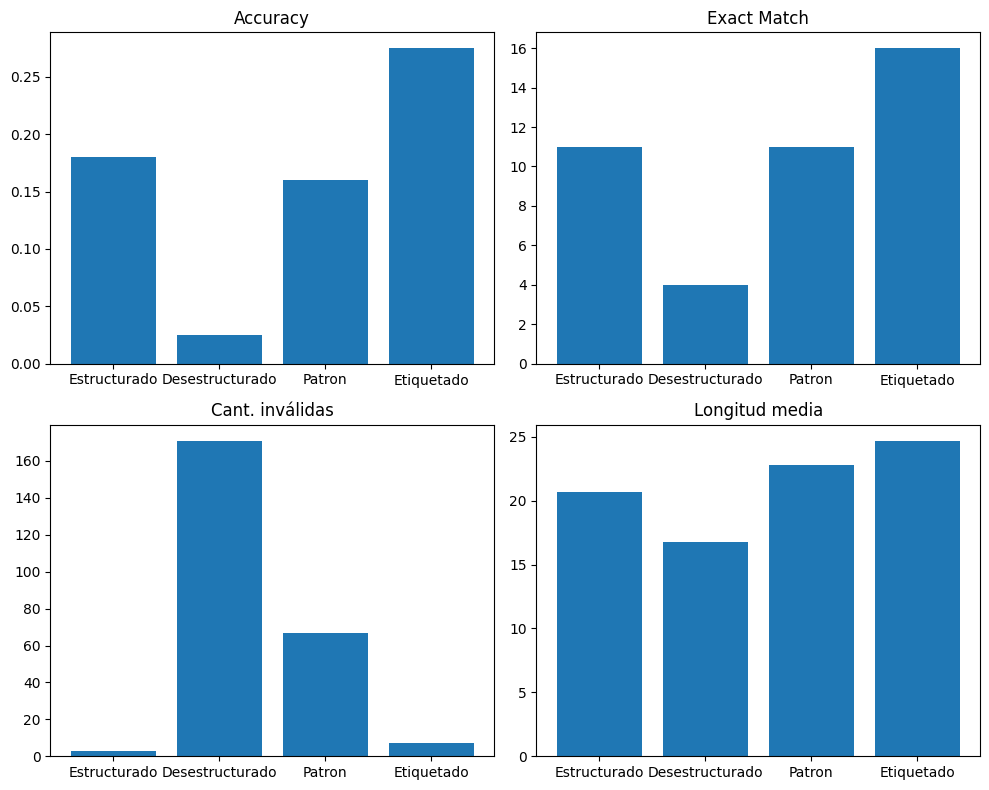

{'Estructurado': (0.18000000000000008, 11, 3, 20.644999999999982), 'Desestructurado': (0.025, 4, 171, 16.769999999999975), 'Patron': (0.16000000000000006, 11, 67, 22.819999999999993), 'Etiquetado': (0.27500000000000013, 16, 7, 24.695)}


In [20]:
def plotear_metricas(resultados):

  metodos = list(resultados.keys())

  accuracy = [v[0] for v in resultados.values()]
  exact_match = [v[1] for v in resultados.values()]
  invalidas = [v[2] for v in resultados.values()]
  longitud = [v[3] for v in resultados.values()]

  fig, axs = plt.subplots(2, 2, figsize=(10, 8))

  # Accuracy
  axs[0, 0].bar(metodos, accuracy)
  axs[0, 0].set_title("Accuracy")

  # Exact match
  axs[0, 1].bar(metodos, exact_match)
  axs[0, 1].set_title("Exact Match")

  # Invalidas
  axs[1, 0].bar(metodos, invalidas)
  axs[1, 0].set_title("Cant. inválidas")

  # Longitud media
  axs[1, 1].bar(metodos, longitud)
  axs[1, 1].set_title("Longitud media")

  plt.tight_layout()
  plt.show()

  print(resultados)

plotear_metricas(resultados)

####Conclusiones
Por lo visto en las gráficas el prompt de  desestructurado es el que produce mayor acuarccy con un 35%, intentaremos mejorar este porcentaje con los siguientes experimentos.
También podemos notar que ninguno produce exact match, esto se debe a que el modelo es decoder only y no limita su respuesta a una sola etiqueta sino a múltiples. A causa de esto mismo también observamos un porcentaje por encima del 50% de respuestas inválidas o sin sentido

###2.2 Cantidad de contexto

¿Cómo influye la cantidad de ejemplos proporcionados al modelo mediante In-Context Learning en la calidad de la clasificación?
Queremos determinar si aumentar la cantidad de ejemplos mejora la capacidad de clasificación y hasta qué punto.
Vamos a probar con:


*   Zero Shot.
*   One-Shot.
*   Few-Shot (3 ejemplos).
*   Few-Shot (5 ejemplos).
*   Many-Shot (10 ejemplos).


In [21]:
def prompt_etiquetado_sin_ejemplos(categories, body):
  prompt = f"""
<CATEGORIES>
{"\n".join(categories)}
</CATEGORIES>

<TASK>
Ticket: {body}
Label:"""
  return prompt

In [22]:
from sklearn.model_selection import train_test_split

def comparar_prompts_cantidad_ejemplos(repes):
  resultados = {
      "Zero-Shot": (0,0,0,0), #para cada tipo de prompt llevamos (acuarcy,exact_match, cant_invalidas,longitud_media)
      "One-Shot": (0,0,0,0),
      "Few-Shot": (0,0,0,0),
      "Few-Shot2": (0,0,0,0),
      "Many-Shot": (0,0,0,0)
  }

  for _ in range(repes):

      # ----- preparamos los ejemplos -----

      uno_cada_clase = (df_en.groupby("queue").sample(n=1).reset_index(drop=True))

      ejemplos_one_shot = uno_cada_clase.sample(n=1, random_state=42)
      ejemplos_few_shot = uno_cada_clase.sample(n=3, random_state=42)
      ejemplos_few_shot2 = uno_cada_clase.sample(n=5, random_state=42)
      ejemplos_many_shot = uno_cada_clase
      # ----- ticket -----

      idx = random.randint(0, len(df_en)-1)

      ticket = df_en.iloc[idx]

      body = ticket["body"]
      real = ticket["queue"]

      prompts = {
          "Zero-Shot":
              prompt_etiquetado_sin_ejemplos(df_en["queue"].unique(),body),

          "One-Shot":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_one_shot[["body","queue"]],body),

          "Few-Shot":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_few_shot[["body","queue"]],body),

          "Few-Shot2":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_few_shot2[["body","queue"]],body),

          "Many-Shot":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_many_shot[["body","queue"]],body)
      }

      # ----- evaluar -----

      for nombre, prompt in prompts.items():

          pred = llamar_llama(prompt,7)

          acuarcy,exact_match,invalida,longitud = extraer_metricas(pred,real,df_en["queue"].unique())

          resultados[nombre] = (
              resultados[nombre][0] + (acuarcy/repes),
              resultados[nombre][1] + exact_match,
              resultados[nombre][2] + invalida,
              resultados[nombre][3] + (longitud/repes)
          )
  return resultados

resultados = comparar_prompts_cantidad_ejemplos(100)

[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transfo

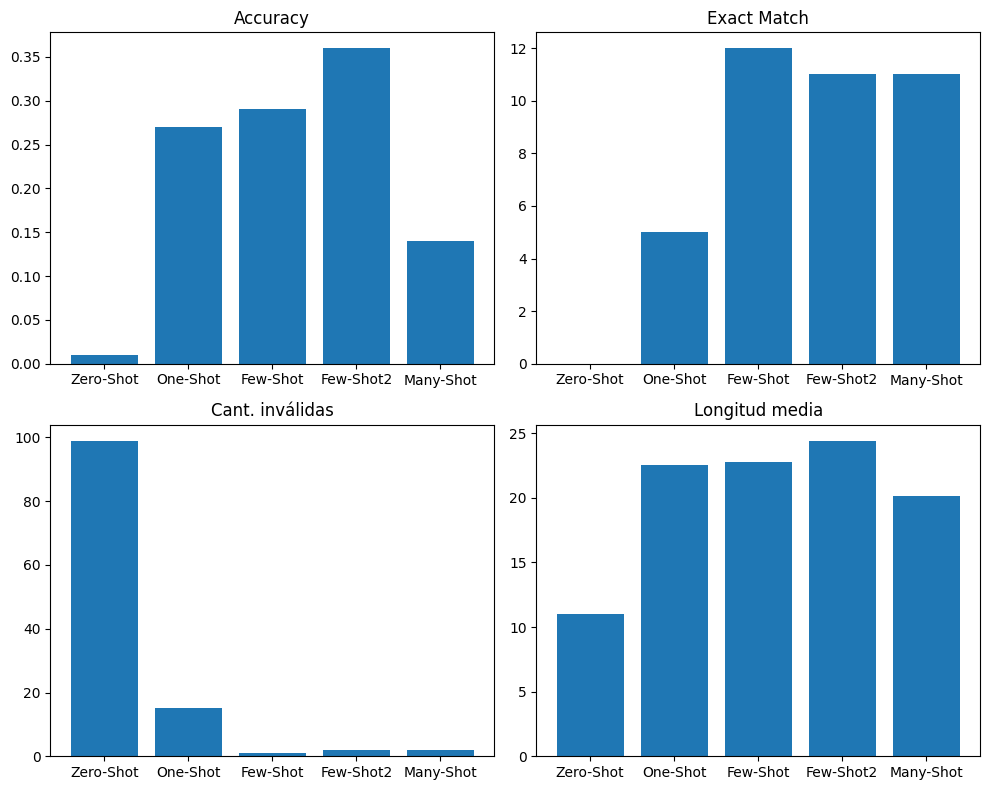

{'Zero-Shot': (0.01, 0, 99, 11.020000000000007), 'One-Shot': (0.2700000000000001, 5, 15, 22.510000000000016), 'Few-Shot': (0.2900000000000001, 12, 1, 22.779999999999998), 'Few-Shot2': (0.36000000000000015, 11, 2, 24.429999999999982), 'Many-Shot': (0.13999999999999999, 11, 2, 20.149999999999967)}


In [23]:
plotear_metricas(resultados)

####Conclusiones
Para el prompt de formato etiquetado logra tanto Few-shot de 3 como de 5 son los que alcanzan los mejores resultados por lo cual avanzaremos con el de 5 ejemplos

###2.3 Calidad del contexto

¿Cómo afecta la calidad de los ejemplos proporcionados en el contexto al desempeño del modelo? Experimentos % de ejemplos correctramente etiquetados:

*   100%
*   75%
*   50%
*   25%
*   0%

In [24]:
def corromper_ejemplos(ejemplos, porcentaje):
    ejemplos2 = ejemplos.copy()

    categorias = ejemplos2["queue"].unique()

    n = int(len(ejemplos2) * porcentaje)

    indices = random.sample(list(ejemplos2.index), n) #indices a ser alterados

    for idx in indices:
        categoria_real = ejemplos2.loc[idx, "queue"]

        posibles = [c for c in categorias if c != categoria_real] #etiquetas posibles para los indices seleccionados

        ejemplos2.loc[idx, "queue"] = random.choice(posibles)

    return ejemplos2

In [25]:
def comparar_prompts_porcentaje_ruido(repes):
  resultados = {
      "0%": (0,0,0,0), #para cada tipo de prompt llevamos (acuarcy,exact_match, cant_invalidas,longitud_media)
      "25%": (0,0,0,0),
      "50%": (0,0,0,0),
      "75%": (0,0,0,0),
      "100%": (0,0,0,0)
  }

  for _ in range(repes):

      # ----- preparamos los ejemplos -----

      uno_cada_clase = (df_en.groupby("queue").sample(n=1).reset_index(drop=True))

      ejemplos = uno_cada_clase.sample(n=5, random_state=42)

      ejemplos_veinticinco = corromper_ejemplos(ejemplos, 0.25)
      ejemplos_cincuenta = corromper_ejemplos(ejemplos, 0.50)
      ejemplos_setentaicinco = corromper_ejemplos(ejemplos, 0.75)
      ejemplos_cien = corromper_ejemplos(ejemplos, 1)

      # ----- ticket -----

      idx = random.randint(0, len(df_en)-1)

      ticket = df_en.iloc[idx]

      body = ticket["body"]
      real = ticket["queue"]

      prompts = {
          "0%":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos[["body","queue"]],body),

          "25%":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_veinticinco[["body","queue"]],body),

          "50%":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_cincuenta[["body","queue"]],body),

          "75%":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_setentaicinco[["body","queue"]],body),

          "100%":
              prompt_etiquetado(df_en["queue"].unique(),ejemplos_cien[["body","queue"]],body)
      }

      # ----- evaluar -----

      for nombre, prompt in prompts.items():

          pred = llamar_llama(prompt,7)

          acuarcy,exact_match,invalida,longitud = extraer_metricas(pred,real,df_en["queue"].unique())

          resultados[nombre] = (
              resultados[nombre][0] + (acuarcy/repes),
              resultados[nombre][1] + exact_match,
              resultados[nombre][2] + invalida,
              resultados[nombre][3] + (longitud/repes)
          )
  return resultados

resultados = comparar_prompts_porcentaje_ruido(100)

[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=7) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transfo

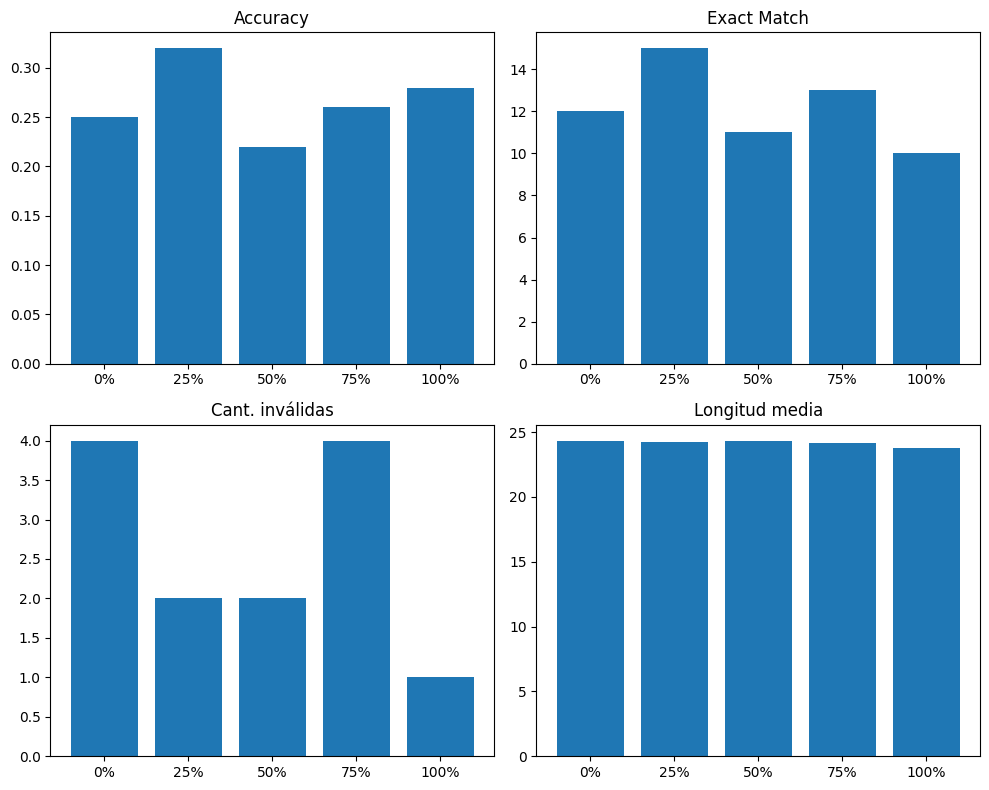

{'0%': (0.25000000000000006, 12, 4, 24.309999999999995), '25%': (0.3200000000000001, 15, 2, 24.20999999999999), '50%': (0.22000000000000006, 11, 2, 24.33999999999999), '75%': (0.26000000000000006, 13, 4, 24.179999999999993), '100%': (0.2800000000000001, 10, 1, 23.759999999999998)}


In [26]:
plotear_metricas(resultados)

Conclusiones:

# Variedad del contexto